In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [13]:
ticker = 'I:NDX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2024-10-29", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

9749757it [05:27, 29772.80it/s]


In [44]:
ticker_hist

,Open,Close,high,low,volume,Datetime,transactions,Date,Time,logClose,logOpen,logReturns
0,12531.599634,12531.599634,12531.599634,12531.599634,None,2023-02-15 09:30:15,None,2023-02-15,09:30:15,9.436009,9.436009,0.0
1,12529.971533,12529.971533,12529.971533,12529.971533,None,2023-02-15 09:30:16,None,2023-02-15,09:30:16,9.435879,9.435879,0.0
2,12530.279774,12530.279774,12530.279774,12530.279774,None,2023-02-15 09:30:17,None,2023-02-15,09:30:17,9.435903,9.435903,0.0
3,12530.934451,12530.934451,12530.934451,12530.934451,None,2023-02-15 09:30:18,None,2023-02-15,09:30:18,9.435956,9.435956,0.0
4,12529.337088,12529.337088,12529.337088,12529.337088,None,2023-02-15 09:30:19,None,2023-02-15,09:30:19,9.435828,9.435828,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9740183,20548.931719,20548.931719,20548.931719,20548.931719,None,2024-10-29 15:59:55,None,2024-10-29,15:59:55,9.930564,9.930564,0.0
9740184,20548.802240,20548.802240,20548.802240,20548.802240,None,2024-10-29 15:59:56,None,2024-10-29,15:59:56,9.930558,9.930558,0.0
9740185,20548.430768,20548.430768,20548.430768,20548.430768,None,2024-10-29 15:59:57,None,2024-10-29,15:59:57,9.930540,9.930540,0.0
9740186,20552.452802,20552.452802,20552.452802,20552.452802,None,2024-10-29 15:59:58,None,2024-10-29,15:59:58,9.930736,9.930736,0.0


In [14]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']


ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    logReturns = ticker_hist_date['logOpen'].diff().iloc[1:]
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


426it [04:39,  1.52it/s]


In [15]:
ab_params_df = pd.DataFrame(ab_params)

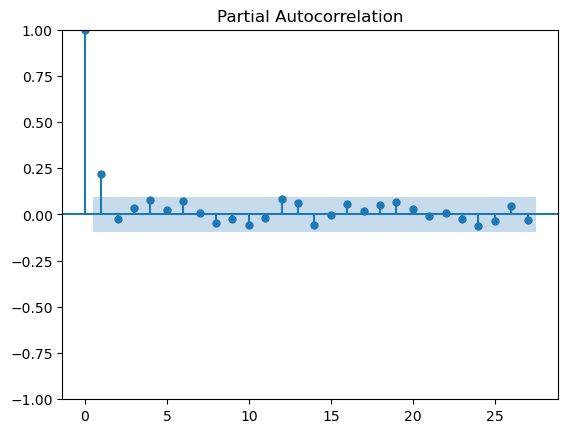

In [16]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

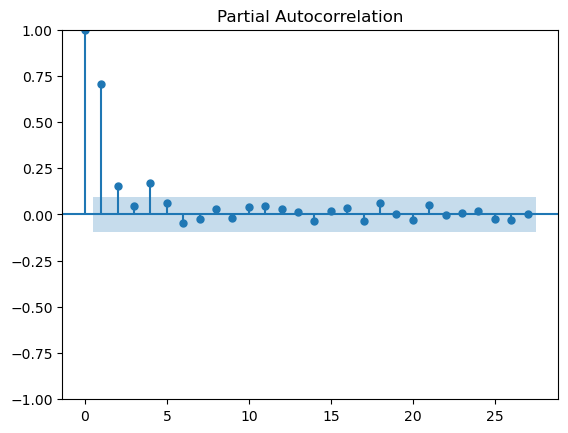

In [17]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [18]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.24922808772725144), pvalue=np.float64(1.9379027587046795e-07))

In [25]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.6859220584327272), pvalue=np.float64(2.242039766466138e-60))

In [20]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.6010598153352066), pvalue=np.float64(5.3685061384087026e-43))

In [21]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(-0.014184083412796424), pvalue=np.float64(0.7706185995345411))

In [26]:
scipy.stats.pearsonr(np.log(ab_params_df['b'].shift(-1).iloc[:-1]), np.log(ab_params_df['b'].iloc[:-1]))

PearsonRResult(statistic=np.float64(0.7302367150680201), pvalue=np.float64(5.449401090579027e-72))

In [27]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.7078318588245062), pvalue=np.float64(7.604341000438461e-66))

In [29]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [45]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.500531815933839
0.07863019986643938


In [32]:
lr_b = LinearRegression()

lr_b.fit(
    np.log(ab_params_df.dropna()[['b']]).values.reshape(-1,1),
    np.log(ab_params_df.dropna()['shifted_b_1'])
)
print(
    lr_b.score(
        np.log(ab_params_df.dropna()[['b']]).values.reshape(-1,1), 
        np.log(ab_params_df.dropna()['shifted_b_1'])
    )
)

0.533245660033333


In [34]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [78]:
r_b = Ridge(alpha=0.000000001)

r_b.fit(
    ab_params_df.dropna()[['b', 'shifted_b_1']],
    ab_params_df.dropna()['shifted_b_2']
)

print(
    r_b.score(
        ab_params_df.dropna()[[ 'b',  'shifted_b_1']],
        ab_params_df.dropna()['shifted_b_2']
    )
)

r_a = Ridge(alpha=0.0000000001)

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5115886022256444
0.06278529188726589


In [79]:
r_b.coef_

array([0.18407968, 0.54310373])

In [49]:
lr_b.coef_

array([0.00932102, 0.7070765 ])

In [50]:
lr_a.coef_

array([0.23547396, 0.01075725])

In [51]:
r_a.coef_

array([0.0093714 , 0.00539662, 0.08551092, 0.00629503])

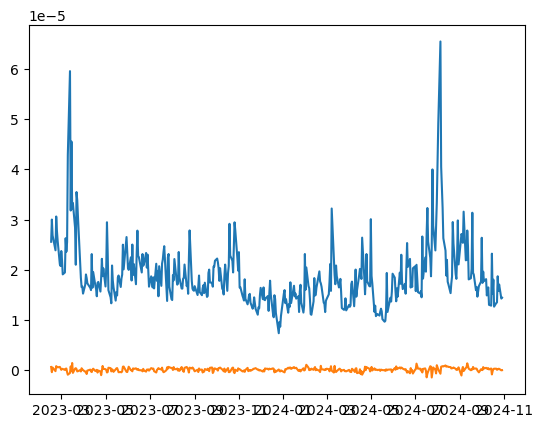

In [52]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

In [53]:
replicates = 100000

In [54]:
ab_params_df

,a,b,shifted_a_1,shifted_b_1,shifted_a_2,shifted_b_2
2023-02-15,6.674455e-07,0.000026,-3.633072e-07,0.000030,5.606803e-07,0.000027
2023-02-16,-3.633072e-07,0.000030,5.606803e-07,0.000027,-1.622911e-07,0.000024
2023-02-17,5.606803e-07,0.000027,-1.622911e-07,0.000024,8.377529e-07,0.000031
2023-02-21,-1.622911e-07,0.000024,8.377529e-07,0.000031,6.883518e-07,0.000028
2023-02-22,8.377529e-07,0.000031,6.883518e-07,0.000028,5.911464e-07,0.000026
...,...,...,...,...,...,...
2024-10-23,1.743169e-07,0.000019,3.105089e-07,0.000016,3.003217e-07,0.000017
2024-10-24,3.105089e-07,0.000016,3.003217e-07,0.000017,0.000000e+00,0.000014
2024-10-25,3.003217e-07,0.000017,0.000000e+00,0.000014,2.962727e-08,0.000014
2024-10-28,0.000000e+00,0.000014,2.962727e-08,0.000014,NaN,NaN


In [62]:
r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']])[-1]

np.float64(9.044104144357255e-08)

In [63]:
r_b.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']])[-1]

np.float64(1.603593667876975e-05)

In [80]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=0., 
        scale=r_b.predict(ab_params_df.dropna()[['b', 'shifted_b_1']])[-1], 
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|██████████████████████████████████| 100000/100000 [04:16<00:00, 389.79it/s]


In [81]:
np.std(possible_final_returns)

np.float64(0.0034582528787490746)

# declare spot ticker price

In [82]:
spot_spx_price = 20615.

In [83]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [84]:
np.mean(possible_final_prices)

np.float64(20615.44920471864)

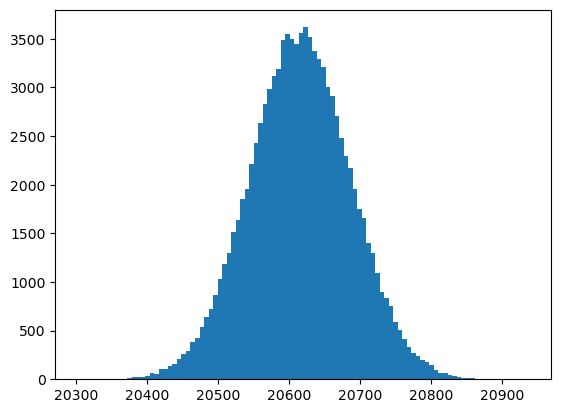

In [85]:
plt.hist(possible_final_prices, bins = 100)
plt.show()

In [89]:
upper_call = 20820.
lower_call = 20810.
upper_put = 20440.
lower_put = 20430.

In [90]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

Text(0.5, 1.0, 'avg payout is -0.08')

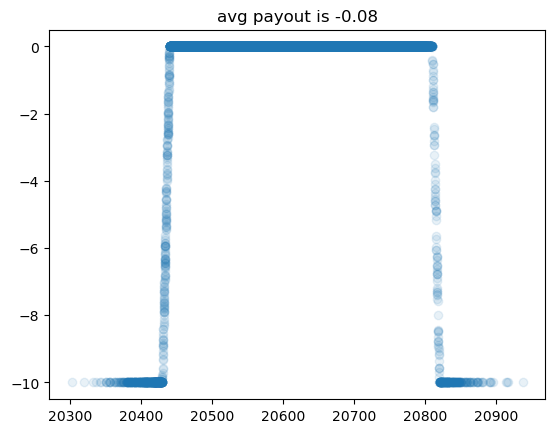

In [91]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

# compute cost of trade and max loss

In [73]:
cost_of_trade = 0.55
max_loss = 5

In [74]:
p = (max_loss - cost_of_trade)/max_loss

In [75]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 2.220446049250313e-16


In [76]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.4408181818181823
